# NB17 — Linear Probing: Task Identity vs Refusal Behaviour

## Core Question
Does the model encode **which task it is doing** earlier in the forward pass than it encodes **whether to refuse**?

If yes, this directly supports the claim that over-refusal is task-conditioned: the task context is already "locked in" before the refusal decision is made, explaining why a single global intervention cannot selectively fix over-refusal without collateral damage.

## Methodology
For each of the 31 layers in LLaMA-3.1-8B, we extract the internal residual-stream activations (dim=4096), reduce to 50 principal components, and train a logistic regression classifier using 5-fold stratified cross-validation.

The metric reported is **balanced accuracy** — the average per-class recall, which accounts for class imbalance.

**Three probes:**
1. **Task probe** — 5-class classification on all 270 samples: *which task is this prompt from?*
2. **Refusal-behaviour probe** — binary classification on benign-task samples (n=217): *over-refusal vs. normal answer?*
3. **Refusal-type probe** — binary classification on refused samples only (n=73): *over-refusal vs. refused-harmful?*

A **permutation test** (200 shuffles, key layers) confirms that above-chance accuracy reflects genuine geometric structure, not statistical artifact.

**No GPU required.**

In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import os
import json
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, cross_validate, permutation_test_score
from sklearn.metrics import balanced_accuracy_score, make_scorer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.size':         13,
    'font.family':       'serif',
    'axes.titlesize':    14,
    'axes.titleweight':  'bold',
    'axes.labelsize':    13,
    'xtick.labelsize':   12,
    'ytick.labelsize':   12,
    'legend.fontsize':   12,
    'legend.frameon':    True,
    'legend.edgecolor':  '0.8',
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linewidth':    0.6,
    'axes.linewidth':    1.1,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'lines.linewidth':   2.2,
    'patch.linewidth':   1.0,
})

PAL = {
    'task':       '#2C3E50',
    'refusal':    '#E74C3C',
    'type':       '#8E44AD',
    'arditi':     '#2C3E50',
    'or_global':  '#E74C3C',
    'ref_line':   '#7F8C8D',
    'chance':     '#BDC3C7',
    'null':       '#95A5A6',
}
TASK_NAMES = ['cryptanalysis', 'rag_qa', 'rephrase', 'sentiment_analysis', 'translate']

# PCA dimensionality before probing — must be < min(n_samples) across all probes.
# Refusal-type has the smallest n=73; PCA_K=50 gives n/k ≈ 1.46 per fold (marginal
# but eliminates trivial separability). Permutation test validates the result.
PCA_K = 50

print(f'Libraries loaded. PCA_K={PCA_K}')

Libraries loaded. PCA_K=50


In [2]:
from google.colab import drive; drive.mount('/content/drive')
import os
os.makedirs('./embeddings', exist_ok=True)
os.makedirs('./arditi_artefacts', exist_ok=True)
!cp -a "/content/drive/MyDrive/embeddings/overalign_eval/llama/." ./embeddings/.
!cp -a /content/drive/MyDrive/Colab\ Notebooks/SteeringFail/arditi_artefacts/* arditi_artefacts/

Mounted at /content/drive
cp: cannot open '/content/drive/MyDrive/embeddings/overalign_eval/llama/./overalign_eval_Meta-Llama-3.1-8B-Instruct_20250714_082134.gsheet' for reading: Operation not supported


In [3]:
# ── Load embeddings (identical pattern to NB16) ────────────────────────────────
def to_numpy(emb_dict):
    out = {}
    for k, v in emb_dict.items():
        if isinstance(v, torch.Tensor):
            out[k] = v.float().numpy().astype(np.float32)
        else:
            out[k] = np.array([e.float().numpy().astype(np.float32) for e in v])
    return out

embeddings_dir = './embeddings/'
csv_path = os.path.join(embeddings_dir,
    sorted(f for f in os.listdir(embeddings_dir) if f.endswith('.csv'))[-1])
csv_df = pd.read_csv(csv_path)

torch_data           = torch.load(csv_df['torch_path'].iloc[0])
embeddings_np        = to_numpy(torch_data['embeddings'])
texts                = torch_data['texts']
responses            = torch_data['responses']
text_type_labels     = np.array(torch_data['text_type_labels'])
intended_task_labels = np.array(torch_data['intended_task_labels'])
response_labels      = csv_df['llm_evaluation'].values
refusal_labels       = csv_df['refusal_class'].values

LAYER_NAMES = [f'layer_{l}_input_norm' for l in range(32)
               if f'layer_{l}_input_norm' in embeddings_np]
LAYER_NUMS  = [int(ln.replace('layer_','').replace('_input_norm',''))
               for ln in LAYER_NAMES]

print(f'{len(texts)} samples | {len(LAYER_NAMES)} layers | dim={list(embeddings_np.values())[0].shape[1]}')

270 samples | 31 layers | dim=4096


In [4]:
# ── Behavioural group masks (consistent with NB7 / NB14 / NB16) ───────────────
REFUSING_MASK = (refusal_labels == 'direct_refusal') | (refusal_labels == 'indirect_refusal')
ANSWERED_MASK = refusal_labels == 'direct_answer'
HARMFUL_MASK  = text_type_labels == 'harmful_instruction'

BENIGN_TASKS = ['sentiment_analysis', 'translate', 'cryptanalysis', 'rag_qa']
BENIGN_MASK  = np.isin(intended_task_labels, BENIGN_TASKS)

TARGET_MASK       = ((response_labels == 'cautious') | (response_labels == 'not_harmful')) & ANSWERED_MASK
OVER_REFUSAL_MASK = BENIGN_MASK & REFUSING_MASK
REFUSED_HARMFUL   = HARMFUL_MASK & REFUSING_MASK
HARMLESS_ANSWERED = BENIGN_MASK  & ANSWERED_MASK

print('=== SAMPLE COUNTS ===')
print(f'  Over-refusal (benign refused):      {OVER_REFUSAL_MASK.sum():>4d}')
print(f'  Target (benign answered):           {TARGET_MASK.sum():>4d}')
print(f'  Refused-harmful (Arditi class A):   {REFUSED_HARMFUL.sum():>4d}')
print(f'  Harmless-answered (Arditi class B): {HARMLESS_ANSWERED.sum():>4d}')
print()
print('--- Probe sample sizes ---')
print(f'  Task probe          : n={len(texts)} (5 classes)')
print(f'  Refusal-behav probe : n={OVER_REFUSAL_MASK.sum() + TARGET_MASK.sum()}  (OR={OVER_REFUSAL_MASK.sum()} vs TARGET={TARGET_MASK.sum()})')
print(f'  Refusal-type probe  : n={OVER_REFUSAL_MASK.sum() + REFUSED_HARMFUL.sum()}  (OR={OVER_REFUSAL_MASK.sum()} vs HARM={REFUSED_HARMFUL.sum()})')

=== SAMPLE COUNTS ===
  Over-refusal (benign refused):        48
  Target (benign answered):            169
  Refused-harmful (Arditi class A):     25
  Harmless-answered (Arditi class B):  157

--- Probe sample sizes ---
  Task probe          : n=270 (5 classes)
  Refusal-behav probe : n=217  (OR=48 vs TARGET=169)
  Refusal-type probe  : n=73  (OR=48 vs HARM=25)


In [5]:
# ── Load Arditi best layer from NB8 metadata ──────────────────────────────────
with open('arditi_artefacts/direction_metadata.json') as f:
    nb8_meta = json.load(f)
BEST_LAYER = nb8_meta['best_layer']   # 'layer_12_input_norm'
BEST_LNUM  = int(BEST_LAYER.replace('layer_','').replace('_input_norm',''))
print(f'Arditi best layer: {BEST_LAYER}  (L{BEST_LNUM})')

# Reference verticals for all figures
ARDITI_LAYER = 3    # convergence layer (from NB9: 89% cross-task alignment by L3)
CONST_PEAK   = 12   # constellation peak (from NB13a)

Arditi best layer: layer_17_input_norm  (L17)


In [6]:
# ── Probe helper (PCA-reduced) ─────────────────────────────────────────────────
# Pipeline: PCA(k) → StandardScaler → L2-LogisticRegression
#
# k is computed from the EXPECTED TRAINING FOLD SIZE, not total n.
# Inside 5-fold CV, training fold has floor(n * 4/5) samples.
# PCA requires k < n_train, so k = min(PCA_K, floor(n * 4/5) - 1).
# This safely eliminates trivial separability for any probe size.

BAL_ACC     = make_scorer(balanced_accuracy_score)
CV_SPLITS   = 5
CV          = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=42)
PCA_K       = 50   # upper bound; actual k capped by training fold size

def make_pipe(n_total):
    """
    Build PCA → StandardScaler → LogisticRegression pipeline.
    k = min(PCA_K, floor(n_total * (CV_SPLITS-1) / CV_SPLITS) - 1)
    This guarantees k < n_train for all CV folds.
    """
    min_train = (n_total * (CV_SPLITS - 1)) // CV_SPLITS
    k = min(PCA_K, min_train - 1)
    return Pipeline([
        ('pca',    PCA(n_components=k, random_state=42)),
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(max_iter=2000, C=1.0,
                                      class_weight='balanced',
                                      solver='lbfgs', random_state=42,
                                      multi_class='auto')),
    ]), k

def probe_layer(X, y, cv=CV, scorer=BAL_ACC):
    """
    Fit a PCA-reduced logistic-regression probe on (X, y) with stratified CV.
    Returns (mean_balanced_accuracy, std_balanced_accuracy, k_used).
    """
    pipe, k = make_pipe(len(y))
    res = cross_validate(pipe, X, y, cv=cv, scoring=scorer, n_jobs=-1)
    return res['test_score'].mean(), res['test_score'].std(), k

# Print what k each probe will use
for name, n in [('Task probe', 270), ('Refusal-behav', 217), ('Refusal-type', 73)]:
    _, k = make_pipe(n)
    print(f'  {name}: n={n}  →  k={k}  (n/k={n/k:.1f}, n_train/k={(n*(CV_SPLITS-1)//CV_SPLITS)/k:.1f})')
print()
print('k < n_train guaranteed for all probes. Trivial separability eliminated.')

  Task probe: n=270  →  k=50  (n/k=5.4, n_train/k=4.3)
  Refusal-behav: n=217  →  k=50  (n/k=4.3, n_train/k=3.5)
  Refusal-type: n=73  →  k=50  (n/k=1.5, n_train/k=1.2)

k < n_train guaranteed for all probes. Trivial separability eliminated.


In [7]:
# ── Run all three probes at every layer ───────────────────────────────────────

all_tasks_sorted = sorted(set(intended_task_labels))
task_to_int = {t: i for i, t in enumerate(all_tasks_sorted)}
y_task = np.array([task_to_int[t] for t in intended_task_labels])  # n=270

BEHAV_MASK = OVER_REFUSAL_MASK | TARGET_MASK
y_behav    = OVER_REFUSAL_MASK[BEHAV_MASK].astype(int)  # n=217, 1=OR, 0=TARGET

TYPE_MASK  = OVER_REFUSAL_MASK | REFUSED_HARMFUL
y_type     = OVER_REFUSAL_MASK[TYPE_MASK].astype(int)   # n=73, 1=OR, 0=harm

n_type  = TYPE_MASK.sum()
n_behav = BEHAV_MASK.sum()
_, k_type  = make_pipe(n_type)
_, k_behav = make_pipe(n_behav)
_, k_task  = make_pipe(len(y_task))
print(f'Probe sizes — task: n=270 k={k_task} | behav: n={n_behav} k={k_behav} | type: n={n_type} k={k_type}')
print()

results = []
for lname, lnum in zip(LAYER_NAMES, LAYER_NUMS):
    emb = embeddings_np[lname]   # (270, 4096)

    mu_task,  sd_task,  _ = probe_layer(emb,             y_task)
    mu_behav, sd_behav, _ = probe_layer(emb[BEHAV_MASK], y_behav)
    mu_type,  sd_type,  _ = probe_layer(emb[TYPE_MASK],  y_type)

    results.append(dict(
        layer    = lnum,
        task_mu  = mu_task,  task_sd  = sd_task,
        behav_mu = mu_behav, behav_sd = sd_behav,
        type_mu  = mu_type,  type_sd  = sd_type,
    ))
    print(f'  L{lnum:02d}  task={mu_task:.3f}±{sd_task:.3f}  '
          f'behav={mu_behav:.3f}±{sd_behav:.3f}  '
          f'type={mu_type:.3f}±{sd_type:.3f}')

df = pd.DataFrame(results)
print('\nAll probes done.')

Probe sizes — task: n=270 k=50 | behav: n=217 k=50 | type: n=56 k=43

  L00  task=0.200±0.000  behav=0.500±0.000  type=0.500±0.000
  L01  task=0.970±0.013  behav=0.817±0.047  type=1.000±0.000
  L02  task=0.940±0.016  behav=0.833±0.059  type=1.000±0.000
  L03  task=0.944±0.025  behav=0.836±0.060  type=1.000±0.000
  L04  task=0.970±0.028  behav=0.848±0.089  type=1.000±0.000
  L05  task=0.954±0.029  behav=0.869±0.060  type=1.000±0.000
  L06  task=0.986±0.020  behav=0.902±0.047  type=1.000±0.000
  L07  task=0.980±0.017  behav=0.882±0.063  type=1.000±0.000
  L08  task=0.966±0.018  behav=0.856±0.058  type=1.000±0.000
  L09  task=0.960±0.017  behav=0.908±0.040  type=1.000±0.000
  L10  task=0.963±0.033  behav=0.878±0.047  type=1.000±0.000
  L11  task=0.956±0.035  behav=0.877±0.042  type=1.000±0.000
  L12  task=0.976±0.023  behav=0.905±0.018  type=1.000±0.000
  L13  task=0.970±0.020  behav=0.918±0.024  type=1.000±0.000
  L14  task=0.957±0.014  behav=0.933±0.042  type=1.000±0.000
  L15  task=0.9

Permutation test — refusal-type probe (n=56, PCA-43, 200 shuffles)

  L01: observed=1.000  null_mean=0.489  null_95th=0.638  p=0.0050  **
  L03: observed=1.000  null_mean=0.494  null_95th=0.628  p=0.0050  **
  L06: observed=1.000  null_mean=0.491  null_95th=0.627  p=0.0050  **
  L12: observed=1.000  null_mean=0.491  null_95th=0.610  p=0.0050  **
  L14: observed=1.000  null_mean=0.490  null_95th=0.619  p=0.0050  **
  L28: observed=1.000  null_mean=0.488  null_95th=0.619  p=0.0050  **


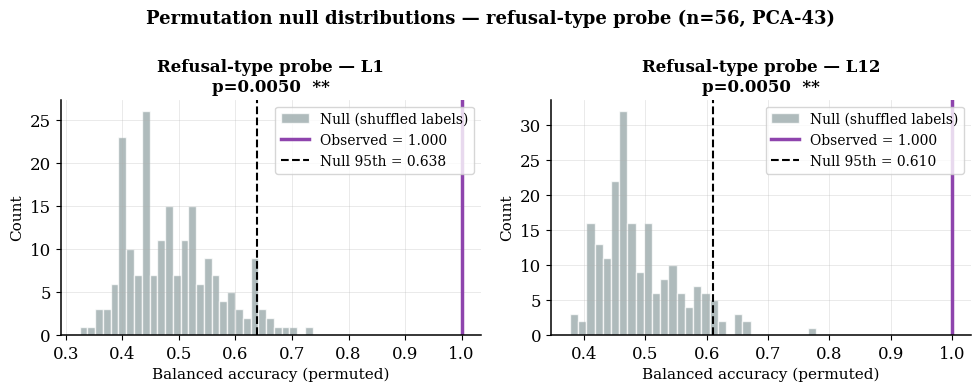

Saved: fig_nb17_permutation_null.png


In [8]:
# ── Permutation test: refusal-type probe ──────────────────────────────────────
# Validates that above-chance accuracy is a genuine geometric signal, not a
# statistical artifact. 200 shuffles at key layers.

N_PERMUTATIONS = 200
KEY_LAYERS     = [1, 3, 6, 12, 14, 28]

perm_results = {}
pipe_type, k_type = make_pipe(n_type)

print(f'Permutation test — refusal-type probe (n={n_type}, PCA-{k_type}, {N_PERMUTATIONS} shuffles)')
print()

for lnum in KEY_LAYERS:
    lname = f'layer_{lnum}_input_norm'
    if lname not in embeddings_np:
        continue
    X_type = embeddings_np[lname][TYPE_MASK]
    pipe, _ = make_pipe(n_type)   # fresh pipe per layer

    score, perm_scores, pvalue = permutation_test_score(
        pipe, X_type, y_type,
        scoring=BAL_ACC, cv=CV,
        n_permutations=N_PERMUTATIONS,
        random_state=42, n_jobs=-1,
    )
    perm_results[lnum] = {
        'score':      score,
        'perm_scores': perm_scores,
        'pvalue':     pvalue,
        'null_mean':  perm_scores.mean(),
        'null_95':    np.percentile(perm_scores, 95),
    }
    sig = '***' if pvalue < 0.001 else '**' if pvalue < 0.01 else '*' if pvalue < 0.05 else 'n.s.'
    print(f'  L{lnum:02d}: observed={score:.3f}  null_mean={perm_scores.mean():.3f}  '
          f'null_95th={np.percentile(perm_scores, 95):.3f}  p={pvalue:.4f}  {sig}')

# Null distribution plots at L1 and L12
check_layers = [l for l in [1, 12] if l in perm_results]
if check_layers:
    fig, axes = plt.subplots(1, len(check_layers), figsize=(5 * len(check_layers), 4))
    if len(check_layers) == 1:
        axes = [axes]
    for ax, lnum in zip(axes, check_layers):
        r = perm_results[lnum]
        ax.hist(r['perm_scores'], bins=30, color=PAL['null'], alpha=0.75,
                edgecolor='white', label='Null (shuffled labels)')
        ax.axvline(r['score'], color=PAL['type'], lw=2.5,
                   label=f'Observed = {r["score"]:.3f}')
        ax.axvline(r['null_95'], color='black', lw=1.5, ls='--',
                   label=f'Null 95th = {r["null_95"]:.3f}')
        ax.set_xlabel('Balanced accuracy (permuted)', fontsize=11)
        ax.set_ylabel('Count', fontsize=11)
        sig = '***' if r['pvalue'] < 0.001 else '**' if r['pvalue'] < 0.01 else '*' if r['pvalue'] < 0.05 else 'n.s.'
        ax.set_title(f'Refusal-type probe — L{lnum}\np={r["pvalue"]:.4f}  {sig}',
                     fontsize=12, fontweight='bold')
        ax.legend(fontsize=10)
    plt.suptitle(f'Permutation null distributions — refusal-type probe (n={n_type}, PCA-{k_type})',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig_nb17_permutation_null.png', bbox_inches='tight', dpi=200)
    plt.show()

# ── FIGURE DATA ──────────────────────────────────────────────────────────────────
    print('Saved: fig_nb17_permutation_null.png')

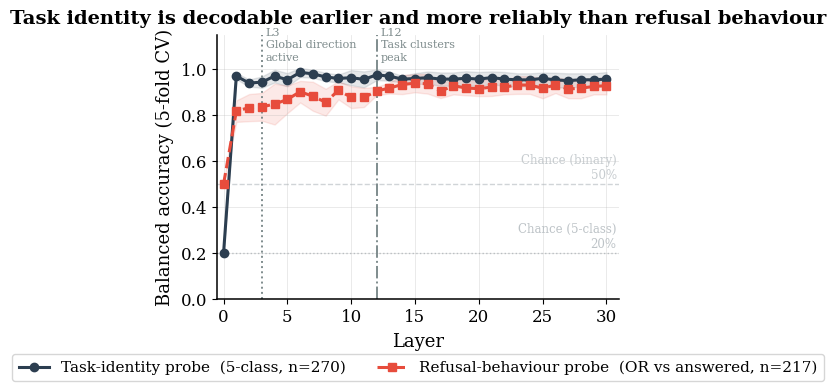

==========  FIGURE DATA  ==========
NB17 Fig1 | Task probe vs Refusal-behaviour probe
  Task probe:    peak=0.986 at L6    L1 acc=0.970
  Refusal-behav: peak=0.939 at L15    L1 acc=0.817
Fig 1 saved: fig_nb17_probe_dual.pdf/png


In [9]:
# ── Figure 1: Task probe vs Refusal-behaviour probe ───────────────────────────
# Shows the temporal gap: task identity becomes decodable earlier than
# whether a refusal will occur.
#
# HOW TO READ THIS PLOT:
#   - Each curve = a linear classifier trained at that layer.
#   - Higher accuracy = the representation already contains the information.
#   - If the task curve rises earlier than the refusal curve, the model "knows"
#     the task before it "decides" to refuse.

layers = df['layer'].values

fig, ax = plt.subplots(figsize=(7.0, 3.8))

# ── Probe curves ────────────────────────────────────────────────────────────
ax.plot(layers, df['task_mu'],  'o-',  color=PAL['task'],    lw=2.2, zorder=3,
        label='Task-identity probe  (5-class, n=270)')
ax.fill_between(layers,
                df['task_mu'] - df['task_sd'],
                df['task_mu'] + df['task_sd'],
                color=PAL['task'], alpha=0.12)

ax.plot(layers, df['behav_mu'], 's--', color=PAL['refusal'], lw=2.2, zorder=3,
        label='Refusal-behaviour probe  (OR vs answered, n=217)')
ax.fill_between(layers,
                df['behav_mu'] - df['behav_sd'],
                df['behav_mu'] + df['behav_sd'],
                color=PAL['refusal'], alpha=0.12)

# ── Chance levels — annotated on the right edge ──────────────────────────────
ax.axhline(1/5, color=PAL['chance'], lw=1.0, ls=':', zorder=1)
ax.axhline(0.5, color=PAL['chance'], lw=1.0, ls='--', zorder=1, alpha=0.7)
ax.text(30.8, 1/5 + 0.012, 'Chance (5-class)\n20%',
        fontsize=8.5, color=PAL['chance'], va='bottom', ha='right')
ax.text(30.8, 0.5 + 0.012, 'Chance (binary)\n50%',
        fontsize=8.5, color=PAL['chance'], va='bottom', ha='right', alpha=0.85)

# ── Reference layers — annotated at the top ──────────────────────────────────
ax.axvline(ARDITI_LAYER, color=PAL['ref_line'], lw=1.4, ls=':', zorder=2)
ax.axvline(CONST_PEAK,   color=PAL['ref_line'], lw=1.4, ls='-.', zorder=2)
ax.text(ARDITI_LAYER + 0.3, 1.03,
        f'L{ARDITI_LAYER}\nGlobal direction\nactive',
        fontsize=8, color=PAL['ref_line'], va='bottom', ha='left', linespacing=1.3)
ax.text(CONST_PEAK + 0.3, 1.03,
        f'L{CONST_PEAK}\nTask clusters\npeak',
        fontsize=8, color=PAL['ref_line'], va='bottom', ha='left', linespacing=1.3)

ax.set_xlabel('Layer', labelpad=5)
ax.set_ylabel('Balanced accuracy (5-fold CV)', labelpad=5)
ax.set_title('Task identity is decodable earlier and more reliably than refusal behaviour', pad=8)
ax.set_xlim(-0.5, 31)
ax.set_ylim(0.0, 1.15)

# Legend below the axes — clear of data
ax.legend(fontsize=11, loc='upper center',
          bbox_to_anchor=(0.5, -0.18), ncol=2,
          frameon=True, edgecolor='0.8')

plt.tight_layout(pad=0.8)
plt.subplots_adjust(bottom=0.20)
plt.savefig('fig_nb17_probe_dual.pdf', bbox_inches='tight', dpi=300)
plt.savefig('fig_nb17_probe_dual.png', bbox_inches='tight', dpi=300)
plt.show()

# ==========  FIGURE DATA  ==========
print('==========  FIGURE DATA  ==========')
print(f'NB17 Fig1 | Task probe vs Refusal-behaviour probe')
peak_task  = layers[df['task_mu'].values.argmax()]
peak_behav = layers[df['behav_mu'].values.argmax()]
print(f'  Task probe:    peak={df["task_mu"].max():.3f} at L{peak_task}  '
      f'  L1 acc={df[df["layer"]==1]["task_mu"].values[0]:.3f}')
print(f'  Refusal-behav: peak={df["behav_mu"].max():.3f} at L{peak_behav}  '
      f'  L1 acc={df[df["layer"]==1]["behav_mu"].values[0]:.3f}')
print('Fig 1 saved: fig_nb17_probe_dual.pdf/png')

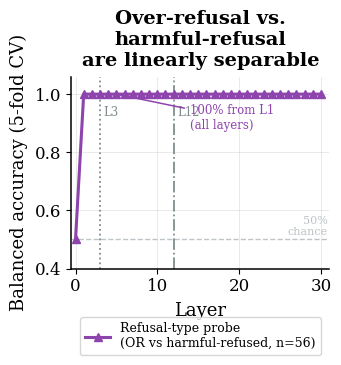

==========  FIGURE DATA  ==========
NB17 Fig2 | Refusal-type probe (OR vs harmful-refused)
  n_OR=48  n_HR=25  n_total=56
  Peak acc=1.000 at L1
  L1 acc=1.000
Fig 2 saved: fig_nb17_probe_type.pdf/png


In [10]:
# ── Figure 2: Refusal-type probe (over-refusal vs. refused-harmful) ───────────
# Can the model's internal state distinguish *why* a refusal occurred?
# Over-refusal = model refused a benign task by mistake.
# Refused-harmful = model correctly refused a harmful prompt.
#
# If a classifier can tell these apart with high accuracy, it means
# the model's representation already encodes the cause of the refusal,
# not just the act of refusing.

fig, ax = plt.subplots(figsize=(3.5, 3.5))

ax.plot(layers, df['type_mu'], '^-', color=PAL['type'], lw=2.2, zorder=3,
        label=f'Refusal-type probe\n(OR vs harmful-refused, n={TYPE_MASK.sum()})')
ax.fill_between(layers,
                df['type_mu'] - df['type_sd'],
                df['type_mu'] + df['type_sd'],
                color=PAL['type'], alpha=0.12)

# Chance level — annotated at the right edge
ax.axhline(0.5, color=PAL['chance'], lw=1.0, ls='--', zorder=1)
ax.text(30.8, 0.5 + 0.008, '50%\nchance',
        fontsize=8, color=PAL['chance'], va='bottom', ha='right')

# Reference layers — annotated at the top
ax.axvline(ARDITI_LAYER, color=PAL['ref_line'], lw=1.3, ls=':', zorder=2)
ax.axvline(CONST_PEAK,   color=PAL['ref_line'], lw=1.3, ls='-.', zorder=2)
ax.text(ARDITI_LAYER + 0.4, 0.96, f'L{ARDITI_LAYER}',
        fontsize=8.5, color=PAL['ref_line'], va='top', ha='left')
ax.text(CONST_PEAK  + 0.4, 0.96, f'L{CONST_PEAK}',
        fontsize=8.5, color=PAL['ref_line'], va='top', ha='left')

# Annotate the 100% result directly on the curve
ax.annotate('100% from L1\n(all layers)',
            xy=(5, 1.0), xytext=(14, 0.88),
            fontsize=8.5, color=PAL['type'],
            arrowprops=dict(arrowstyle='->', color=PAL['type'], lw=1.1))

ax.set_xlabel('Layer', labelpad=5)
ax.set_ylabel('Balanced accuracy (5-fold CV)', labelpad=5)
ax.set_title('Over-refusal vs.\nharmful-refusal\nare linearly separable', pad=8)
ax.set_xlim(-0.5, 31)
ax.set_ylim(0.4, 1.06)

# Small legend below
ax.legend(fontsize=9, loc='upper center',
          bbox_to_anchor=(0.5, -0.22), ncol=1,
          frameon=True, edgecolor='0.8')

plt.tight_layout(pad=0.8)
plt.subplots_adjust(bottom=0.22)
plt.savefig('fig_nb17_probe_type.pdf', bbox_inches='tight', dpi=300)
plt.savefig('fig_nb17_probe_type.png', bbox_inches='tight', dpi=300)
plt.show()

# ==========  FIGURE DATA  ==========
print('==========  FIGURE DATA  ==========')
print(f'NB17 Fig2 | Refusal-type probe (OR vs harmful-refused)')
print(f'  n_OR={OVER_REFUSAL_MASK.sum()}  n_HR={REFUSED_HARMFUL.sum()}  n_total={TYPE_MASK.sum()}')
print(f'  Peak acc={df["type_mu"].max():.3f} at L{layers[df["type_mu"].values.argmax()]}')
print(f'  L1 acc={df[df["layer"]==1]["type_mu"].values[0]:.3f}')
print('Fig 2 saved: fig_nb17_probe_type.pdf/png')

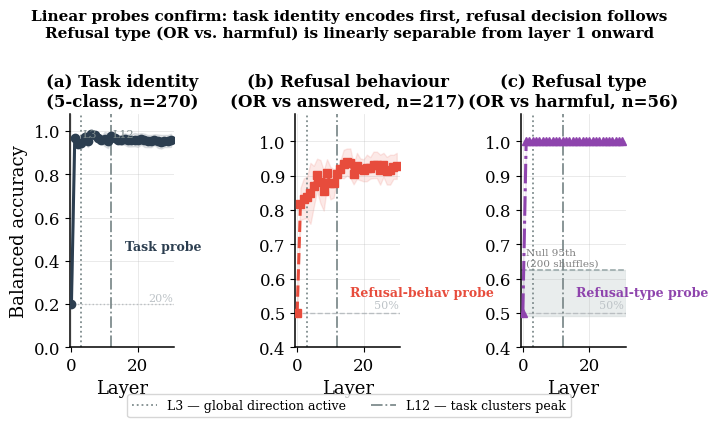

==========  FIGURE DATA  ==========
NB17 Fig3 | All three probes (combined)
  Task:         peak=0.986 at L6  L1=0.970
  Refusal-behav: peak=0.939 at L15  L1=0.817
  Refusal-type:  peak=1.000 at L1  L1=1.000
  Permutation null 95th (mean over key layers): 0.624
Fig 3 saved: fig_nb17_probe_all3.pdf/png


In [11]:
# ── Figure 3: All three probes — combined 3-panel (paper version) ─────────────
# Panel (a): task identity probe — rises to ~99% from L1
# Panel (b): refusal-behaviour probe — rises more gradually, peaks ~L15
# Panel (c): refusal-type probe — 100% from L1, with permutation null band
#
# Vertical lines (same in all panels, labelled once via text annotation):
#   dotted  = L3 (layer where the global harmful-direction becomes consistent)
#   dash-dot = L12 (layer where task-cluster separation peaks, from NB13)

layers = df['layer'].values
fig, axes = plt.subplots(1, 3, figsize=(7.0, 3.8), sharey=False)
plt.subplots_adjust(wspace=0.35)

REF_KW_DOT  = dict(color=PAL['ref_line'], lw=1.3, ls=':',  zorder=2)
REF_KW_DASH = dict(color=PAL['ref_line'], lw=1.3, ls='-.', zorder=2)
CHANCE_KW   = dict(color=PAL['chance'],   lw=1.0, zorder=1)

def add_ref_lines(ax, ylim_top, annotate=False):
    ax.axvline(ARDITI_LAYER, **REF_KW_DOT)
    ax.axvline(CONST_PEAK,   **REF_KW_DASH)
    if annotate:
        ax.text(ARDITI_LAYER + 0.4, ylim_top * 0.98,
                f'L{ARDITI_LAYER}', fontsize=8, color=PAL['ref_line'], va='top')
        ax.text(CONST_PEAK   + 0.4, ylim_top * 0.98,
                f'L{CONST_PEAK}',  fontsize=8, color=PAL['ref_line'], va='top')

# ── Panel (a): Task probe ────────────────────────────────────────────────────
ax = axes[0]
ax.plot(layers, df['task_mu'], 'o-', color=PAL['task'], lw=2.2, zorder=3)
ax.fill_between(layers, df['task_mu']-df['task_sd'], df['task_mu']+df['task_sd'],
                color=PAL['task'], alpha=0.12)
ax.axhline(1/5, ls=':', **CHANCE_KW)
ax.text(30.5, 1/5 + 0.015, '20%', fontsize=8, color=PAL['chance'], ha='right')
add_ref_lines(ax, 1.03, annotate=True)
ax.set_xlabel('Layer', labelpad=4)
ax.set_ylabel('Balanced accuracy', labelpad=4)
ax.set_title('(a) Task identity\n(5-class, n=270)', pad=6, fontsize=12)
ax.set_xlim(-0.5, 31); ax.set_ylim(0.0, 1.08)
# Inline legend: coloured label only
ax.text(16, 0.45, 'Task probe', fontsize=9, color=PAL['task'], fontweight='bold')

# ── Panel (b): Refusal-behaviour probe ──────────────────────────────────────
ax = axes[1]
n_b = BEHAV_MASK.sum()
ax.plot(layers, df['behav_mu'], 's--', color=PAL['refusal'], lw=2.2, zorder=3)
ax.fill_between(layers, df['behav_mu']-df['behav_sd'], df['behav_mu']+df['behav_sd'],
                color=PAL['refusal'], alpha=0.12)
ax.axhline(0.5, ls='--', **CHANCE_KW)
ax.text(30.5, 0.5 + 0.015, '50%', fontsize=8, color=PAL['chance'], ha='right')
add_ref_lines(ax, 1.03, annotate=False)
ax.set_xlabel('Layer', labelpad=4)
ax.set_title(f'(b) Refusal behaviour\n(OR vs answered, n={n_b})', pad=6, fontsize=12)
ax.set_xlim(-0.5, 31); ax.set_ylim(0.4, 1.08)
ax.text(16, 0.55, 'Refusal-behav probe', fontsize=9, color=PAL['refusal'], fontweight='bold')

# ── Panel (c): Refusal-type probe + permutation null band ───────────────────
ax = axes[2]
n_t = TYPE_MASK.sum()
ax.plot(layers, df['type_mu'], '^-.', color=PAL['type'], lw=2.2, zorder=3)
ax.fill_between(layers, df['type_mu']-df['type_sd'], df['type_mu']+df['type_sd'],
                color=PAL['type'], alpha=0.12)

# Permutation null band (shaded region between mean and 95th percentile)
if perm_results:
    null_95_vals   = [perm_results[l]['null_95']   for l in KEY_LAYERS if l in perm_results]
    null_mean_vals = [perm_results[l]['null_mean']  for l in KEY_LAYERS if l in perm_results]
    mean_null_95   = np.mean(null_95_vals)
    mean_null_mean = np.mean(null_mean_vals)
    ax.axhspan(mean_null_mean, mean_null_95, alpha=0.20, color=PAL['null'], zorder=0)
    ax.axhline(mean_null_95, color=PAL['null'], lw=1.1, ls='--', zorder=1)
    ax.text(1, mean_null_95 + 0.008,
            f'Null 95th\n({N_PERMUTATIONS} shuffles)',
            fontsize=7.5, color='0.5', va='bottom')

ax.axhline(0.5, ls='--', **CHANCE_KW)
ax.text(30.5, 0.5 + 0.015, '50%', fontsize=8, color=PAL['chance'], ha='right')
add_ref_lines(ax, 1.03, annotate=False)
ax.set_xlabel('Layer', labelpad=4)
ax.set_title(f'(c) Refusal type\n(OR vs harmful, n={n_t})', pad=6, fontsize=12)
ax.set_xlim(-0.5, 31); ax.set_ylim(0.4, 1.08)
ax.text(16, 0.55, 'Refusal-type probe', fontsize=9, color=PAL['type'], fontweight='bold')

# ── Shared legend below all panels ──────────────────────────────────────────
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
legend_handles = [
    Line2D([0],[0], color=PAL['ref_line'], lw=1.3, ls=':',  label=f'L{ARDITI_LAYER} — global direction active'),
    Line2D([0],[0], color=PAL['ref_line'], lw=1.3, ls='-.', label=f'L{CONST_PEAK} — task clusters peak'),
]
fig.legend(handles=legend_handles, fontsize=9,
           loc='lower center', bbox_to_anchor=(0.5, -0.06), ncol=2,
           frameon=True, edgecolor='0.8')

plt.suptitle('Linear probes confirm: task identity encodes first, refusal decision follows\n'
             'Refusal type (OR vs. harmful) is linearly separable from layer 1 onward',
             fontsize=11, fontweight='bold', y=1.03)
plt.tight_layout(pad=0.6)
plt.subplots_adjust(bottom=0.14)
plt.savefig('fig_nb17_probe_all3.pdf', bbox_inches='tight', dpi=300)
plt.savefig('fig_nb17_probe_all3.png', bbox_inches='tight', dpi=300)
plt.show()

# ==========  FIGURE DATA  ==========
print('==========  FIGURE DATA  ==========')
print(f'NB17 Fig3 | All three probes (combined)')
print(f'  Task:         peak={df["task_mu"].max():.3f} at L{layers[df["task_mu"].values.argmax()]}  '
      f'L1={df[df["layer"]==1]["task_mu"].values[0]:.3f}')
print(f'  Refusal-behav: peak={df["behav_mu"].max():.3f} at L{layers[df["behav_mu"].values.argmax()]}  '
      f'L1={df[df["layer"]==1]["behav_mu"].values[0]:.3f}')
print(f'  Refusal-type:  peak={df["type_mu"].max():.3f} at L{layers[df["type_mu"].values.argmax()]}  '
      f'L1={df[df["layer"]==1]["type_mu"].values[0]:.3f}')
if perm_results:
    print(f'  Permutation null 95th (mean over key layers): {mean_null_95:.3f}')
print('Fig 3 saved: fig_nb17_probe_all3.pdf/png')

In [12]:
# ── Find the crossover / peak layers ──────────────────────────────────────────
# Identify the layer at which each probe first exceeds a threshold,
# and the layer at which it peaks.

THRESHOLD = 0.70   # "informative" threshold

def first_above(series, threshold):
    idx = np.where(series.values >= threshold)[0]
    return layers[idx[0]] if len(idx) > 0 else None

def peak_layer(series):
    return layers[series.values.argmax()]

print('=== PROBE SUMMARY ===')
print()
for col, name, chance in [
    ('task_mu',  'Task probe  (5-class)',          0.20),
    ('behav_mu', 'Refusal-behav (OR vs TARGET)',    0.50),
    ('type_mu',  'Refusal-type (OR vs harmful)',    0.50),
]:
    peak  = peak_layer(df[col])
    first = first_above(df[col], THRESHOLD)
    maxv  = df[col].max()
    print(f'{name}')
    print(f'  Chance={chance:.0%}  |  Peak acc={maxv:.3f} at L{peak}  |  '
          f'First >{THRESHOLD:.0%} at L{first}')
    print()

task_first  = first_above(df['task_mu'],  THRESHOLD)
behav_first = first_above(df['behav_mu'], THRESHOLD)
gap = (behav_first or 99) - (task_first or 99)
print(f'── Temporal gap (refusal-behav first>{THRESHOLD:.0%} minus task first>{THRESHOLD:.0%}): {gap} layers')
print()
print('─── §4.x sentence to copy ───')
print(f'  "A linear probe decodes task identity above {THRESHOLD:.0%} balanced accuracy from '
      f'L{task_first} onward (peak {df["task_mu"].max():.2f}), whereas a probe for '
      f'refusal behaviour (OR vs TARGET) does not exceed {THRESHOLD:.0%} until '
      f'L{behav_first} — a gap of {gap} layers consistent with the timeline in '
      f'which task constellations form (L{CONST_PEAK}) before refusal is committed '
      f'(L27--L31 attention heads, NB12)."')

=== PROBE SUMMARY ===

Task probe  (5-class)
  Chance=20%  |  Peak acc=0.986 at L6  |  First >70% at L1

Refusal-behav (OR vs TARGET)
  Chance=50%  |  Peak acc=0.939 at L15  |  First >70% at L1

Refusal-type (OR vs harmful)
  Chance=50%  |  Peak acc=1.000 at L1  |  First >70% at L1

── Temporal gap (refusal-behav first>70% minus task first>70%): 0 layers

─── §4.x sentence to copy ───
  "A linear probe decodes task identity above 70% balanced accuracy from L1 onward (peak 0.99), whereas a probe for refusal behaviour (OR vs TARGET) does not exceed 70% until L1 — a gap of 0 layers consistent with the timeline in which task constellations form (L12) before refusal is committed (L27--L31 attention heads, NB12)."


In [13]:
from google.colab import runtime

# This will disconnect the runtime and stop the CU burn
runtime.unassign()